
Cluster vs Species Distribution:

cluster  Species                                  
0        Adelie Penguin (Pygoscelis adeliae)          127
         Chinstrap penguin (Pygoscelis antarctica)      5
1        Gentoo penguin (Pygoscelis papua)            123
2        Chinstrap penguin (Pygoscelis antarctica)     63
         Adelie Penguin (Pygoscelis adeliae)           25
         Gentoo penguin (Pygoscelis papua)              1
Name: count, dtype: int64

Cluster Feature Means:

         Culmen Length (mm)  Culmen Depth (mm)  Flipper Length (mm)  \
cluster                                                               
0                 38.208333          18.110606           188.401515   
1                 47.504878          14.982114           217.186992   
2                 47.525287          18.762069           196.896552   

         Body Mass (g)  
cluster                 
0          3584.659091  
1          5076.016260  
2          3902.011494  


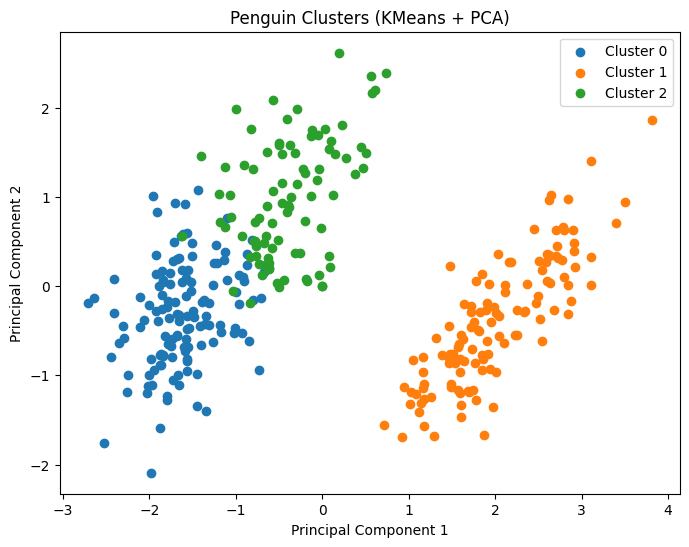

   cluster                           dominant_species    purity
0        0        Adelie Penguin (Pygoscelis adeliae)  0.962121
1        2  Chinstrap penguin (Pygoscelis antarctica)  0.707865
2        1          Gentoo penguin (Pygoscelis papua)  1.000000


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("penguins_lter.csv")

#  Keep only relevant features
features = [
    "Culmen Length (mm)",
    "Culmen Depth (mm)",
    "Flipper Length (mm)",
    "Body Mass (g)"
]

X = df[features]

# Handle missing values
X = X.fillna(X.mean())

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

# Evaluation (Cluster vs Species)
print("\nCluster vs Species Distribution:\n")
print(df.groupby("cluster")["Species"].value_counts())

#Cluster statistics
stats = df.groupby("cluster")[features].mean()
print("\nCluster Feature Means:\n")
print(stats)

# PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

for cluster in range(3):
    plt.scatter(
        X_pca[df["cluster"] == cluster, 0],
        X_pca[df["cluster"] == cluster, 1],
        label=f"Cluster {cluster}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Penguin Clusters (KMeans + PCA)")
plt.legend()
plt.show()

#Purity Table
purity_table = []

for cluster in df["cluster"].unique():
    cluster_data = df[df["cluster"] == cluster]
    counts = cluster_data["Species"].value_counts()

    purity_table.append({
        "cluster": cluster,
        "dominant_species": counts.index[0],
        "purity": counts.iloc[0] / counts.sum()
    })

print(pd.DataFrame(purity_table))